# JPEG AI as a Threat to Deepfake Detection
**Computer Vision — Prof. Irene Amerini — Spring 2026**

Project structure:
1. **Imports** — all required packages
2. **Globals** — project-wide constants and paths
3. **Utils** — helper functions
4. **Data** — dataset loading and JPEG AI compression pipeline
5. **Network** — deepfake detector definitions
6. **Train** — fine-tuning loop (mitigation strategy 1)
7. **Evaluation** — metrics, frequency analysis, mitigation comparison

---
## 1. Imports

In [1]:
import os
import sys
import random
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import cv2
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve

# Project modules
sys.path.insert(0, str(Path.cwd()))
from src.compression.jpegai_codec import compress_dataset, BPP_LEVELS

_rocm = bool(getattr(torch.version, "hip", None))
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()} | ROCm: {_rocm}")


PyTorch 2.9.1+rocm6.3 | CUDA available: True | ROCm: True


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


---
## 2. Globals

In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
# ROCm (AMD) and CUDA (NVIDIA) both surface as torch.cuda.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    _backend = "ROCm/AMD" if getattr(torch.version, "hip", None) else "CUDA/NVIDIA"
    print(f"Using device: cuda [{_backend}] — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("Using device: cpu")

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT          = Path.cwd()
DATA_DIR      = ROOT / "data"
ORIGINAL_DIR  = DATA_DIR / "original"     # raw dataset images
COMPRESSED_DIR= DATA_DIR / "compressed"   # JPEG AI outputs
RESULTS_DIR   = ROOT / "results"
CHECKPOINTS_DIR = ROOT / "checkpoints"

for d in [DATA_DIR, ORIGINAL_DIR, COMPRESSED_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Compression settings ──────────────────────────────────────────────────────
# BPP levels for the degradation curve
BPP_LEVELS    = [0.1, 0.3, 0.5, 0.8, 1.0, 2.0]
JPEGAI_PROFILE= "base"

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 32
NUM_EPOCHS    = 10
LR            = 1e-4
IMG_SIZE      = 224

# ── Dataset split ─────────────────────────────────────────────────────────────
# Expected folder structure inside ORIGINAL_DIR:
#   original/
#     real/   ← genuine images   (label 0)
#     fake/   ← deepfake images  (label 1)
LABEL_MAP = {"real": 0, "fake": 1}


Using device: cuda [ROCm/AMD] — AMD Radeon Graphics


---
## 3. Utils

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def compute_power_spectrum(img_gray: np.ndarray) -> np.ndarray:
    """2D power spectrum (log magnitude) of a grayscale image."""
    f = np.fft.fft2(img_gray.astype(np.float32))
    fshift = np.fft.fftshift(f)
    return 20 * np.log(np.abs(fshift) + 1e-8)


def azimuthal_average(spectrum_2d: np.ndarray) -> np.ndarray:
    """Radial (azimuthal) average of a 2D spectrum → 1D frequency profile."""
    h, w = spectrum_2d.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    max_r = min(cy, cx)
    profile = np.array([spectrum_2d[r == i].mean() for i in range(max_r)])
    return profile


def compute_dct_histogram(img_gray: np.ndarray, bins: int = 256) -> tuple:
    """DCT coefficient histogram of a grayscale image (block size 8×8)."""
    h, w = img_gray.shape
    h = (h // 8) * 8
    w = (w // 8) * 8
    img = img_gray[:h, :w].astype(np.float32)
    coeffs = []
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = img[i:i+8, j:j+8]
            dct = cv2.dct(block)
            coeffs.append(dct.flatten())
    all_coeffs = np.concatenate(coeffs)
    hist, edges = np.histogram(all_coeffs, bins=bins, range=(-100, 100))
    return hist, edges


def evaluate_detector(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device = DEVICE,
) -> dict:
    """Run inference and return AUC, accuracy, F1."""
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    preds = (np.array(all_probs) >= 0.5).astype(int)
    return {
        "auc":      roc_auc_score(all_labels, all_probs),
        "accuracy": accuracy_score(all_labels, preds),
        "f1":       f1_score(all_labels, preds),
        "labels":   np.array(all_labels),
        "probs":    np.array(all_probs),
    }


def plot_degradation_curve(results: dict, metric: str = "auc", title: str = "") -> None:
    """
    Plot detector metric vs BPP.
    results: {detector_name: {bpp: metric_value}}
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    for detector_name, bpp_metrics in results.items():
        bpps = sorted(bpp_metrics.keys())
        vals = [bpp_metrics[b] for b in bpps]
        ax.plot(bpps, vals, marker="o", label=detector_name)
    ax.set_xlabel("BPP (bits per pixel)")
    ax.set_ylabel(metric.upper())
    ax.set_title(title or f"Detector {metric.upper()} vs JPEG AI BPP")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"degradation_{metric}.png", dpi=150)
    plt.show()

---
## 4. Data
### 4.1 Dataset class

### 4.0 FaceForensics++ — Dataset structure

FF++ was downloaded with compression level **c23** (H.264 videos), real sequences from **youtube**:

```
data/ff++/
  original_sequences/youtube/c23/videos/      ← real .mp4
  manipulated_sequences/Deepfakes/c23/videos/ ← fake .mp4
```

Frames were pre-extracted via `scripts/extract_frames.sh` (ffmpeg) into:

```
data/original/
  real/   ← PNG frames from youtube videos   (label 0)
  fake/   ← PNG frames from Deepfakes videos (label 1)
```

The cell below verifies that everything is in place.

In [4]:
from pathlib import Path

# ── FF++ source video paths (c23, already downloaded) ────────────────────────
FF_ROOT  = DATA_DIR / "ff++"
real_src = FF_ROOT / "original_sequences" / "youtube" / "c23" / "videos"
fake_src = FF_ROOT / "manipulated_sequences" / "Deepfakes" / "c23" / "videos"

for label, src in [("real", real_src), ("fake", fake_src)]:
    if src.exists():
        n = len(list(src.glob("*.mp4")))
        print(f"FF++ {label} videos : {n}  ({src})")
    else:
        print(f"FF++ {label} source NOT found: {src}")

# ── Pre-extracted frames (output of scripts/extract_frames.sh) ───────────────
OUT_REAL = ORIGINAL_DIR / "real"
OUT_FAKE = ORIGINAL_DIR / "fake"

real_n = len(list(OUT_REAL.rglob("*.png"))) + len(list(OUT_REAL.rglob("*.jpg"))) if OUT_REAL.exists() else 0
fake_n = len(list(OUT_FAKE.rglob("*.png"))) + len(list(OUT_FAKE.rglob("*.jpg"))) if OUT_FAKE.exists() else 0

print(f"\nExtracted frames in data/original/")
print(f"  real : {real_n}")
print(f"  fake : {fake_n}")

if real_n == 0 or fake_n == 0:
    print("\n⚠  No frames found — run frame extraction first:")
    print("   bash scripts/extract_frames.sh data/ff++ data/original")
else:
    print("\n✓ Dataset ready.")


FF++ real videos : 200  (/home/cascatetto/ssd/Projects/jpegai-deepfake-forensics/jpegai-deepfake-forensics/data/ff++/original_sequences/youtube/c23/videos)
FF++ fake videos : 200  (/home/cascatetto/ssd/Projects/jpegai-deepfake-forensics/jpegai-deepfake-forensics/data/ff++/manipulated_sequences/Deepfakes/c23/videos)

Extracted frames in data/original/
  real : 10420
  fake : 10420

✓ Dataset ready.


In [5]:
class DeepfakeDataset(Dataset):
    """
    Loads images from a directory with 'real/' and 'fake/' subdirectories.
    Works for both original and JPEG-AI-compressed splits.
    """
    def __init__(self, root: Path, transform=None, label_map: dict = LABEL_MAP):
        self.samples = []
        for cls_name, label in label_map.items():
            cls_dir = root / cls_name
            if not cls_dir.exists():
                continue
            for p in sorted(cls_dir.rglob("*.png")) + sorted(cls_dir.rglob("*.jpg")):
                self.samples.append((p, label))
        self.transform = transform or T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


def make_dataloader(root: Path, batch_size: int = BATCH_SIZE, shuffle: bool = False) -> DataLoader:
    ds = DeepfakeDataset(root)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=4, pin_memory=True)


# Verify dataset structure
print("Original dataset:")
for cls in ["real", "fake"]:
    cls_dir = ORIGINAL_DIR / cls
    count = len(list(cls_dir.rglob("*.png"))) + len(list(cls_dir.rglob("*.jpg"))) if cls_dir.exists() else 0
    print(f"  {cls}: {count} images")

Original dataset:
  real: 10420 images
  fake: 10420 images


### 4.2 JPEG AI Compression Pipeline

> **Run this step inside the `jpeg_ai_vm` conda env (Linux native).**  
> The compressed images are saved to `data/compressed/` and reused in all subsequent cells.  
> Skip this cell if `data/compressed/` already exists.

In [ ]:
# ── Option A: Python API (if running inside jpeg_ai_vm env) ──────────────────
# compress_dataset(
#     dataset_dir=ORIGINAL_DIR,
#     output_root=COMPRESSED_DIR,
#     bpp_levels=BPP_LEVELS,
#     profile=JPEGAI_PROFILE,
# )

# ── Option B: Shell script (Linux native) ─────────────────────────────────────
# Run in terminal:
#   conda activate jpeg_ai_vm
#   bash scripts/compress_dataset.sh data/original data/compressed

# ── Verify compressed data exists ────────────────────────────────────────────
for bpp in BPP_LEVELS:
    bpp_tag = f"bpp_{int(bpp*100):03d}"
    bpp_dir = COMPRESSED_DIR / bpp_tag
    count = len(list(bpp_dir.rglob("*.png"))) if bpp_dir.exists() else 0
    status = "OK" if count > 0 else "MISSING"
    print(f"  [{status}] {bpp_tag}: {count} images")


---
## 5. Network
### 5.1 Detector definitions

In [6]:
import timm

def load_detector(name: str, pretrained: bool = True, num_classes: int = 2) -> nn.Module:
    """
    Load a deepfake detector backbone.

    Supported names:
        'resnet50'        — CNNDetection-style (Wang et al., CVPR 2020)
        'efficientnet_b4' — EfficientNet (timm)
        'xception'        — FaceForensics++ baseline
    """
    model = timm.create_model(name, pretrained=pretrained, num_classes=num_classes)
    return model.to(DEVICE)


# TODO: load pre-trained forensics weights if available.
# Example: CNNDetection weights from https://github.com/peterwang512/CNNDetection
#
# detector = load_detector('resnet50', pretrained=False)
# ckpt = torch.load('checkpoints/cnndetection_resnet50.pth', map_location=DEVICE)
# detector.load_state_dict(ckpt)

detector_names = ["resnet50", "efficientnet_b4"]
print("Detectors:", detector_names)

Detectors: ['resnet50', 'efficientnet_b4']


---
## 6. Train
### 6.1 Fine-tuning loop (Mitigation Strategy 1: compression-augmented training)

In [7]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device = DEVICE,
) -> float:
    model.train()
    total_loss = 0.0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


def finetune(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = NUM_EPOCHS,
    lr: float = LR,
    save_path: Path = None,
) -> list:
    """Fine-tune detector. Returns list of val-AUC per epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        metrics = evaluate_detector(model, val_loader)
        scheduler.step()
        history.append(metrics["auc"])
        print(f"Epoch {epoch:02d} | loss {train_loss:.4f} | val AUC {metrics['auc']:.4f}")

    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"Checkpoint saved: {save_path}")
    return history


# ── Compression-augmented dataset for fine-tuning ────────────────────────────
class AugmentedDeepfakeDataset(Dataset):
    """
    Mixes original + JPEG-AI-compressed images for robust fine-tuning.
    Randomly picks original or one compressed variant per sample each epoch.
    """
    def __init__(self, original_root: Path, compressed_root: Path,
                 bpp_levels: list = BPP_LEVELS, transform=None):
        self.base = DeepfakeDataset(original_root, transform)
        self.compressed_roots = [
            compressed_root / f"bpp_{int(b*100):03d}" for b in bpp_levels
        ]
        self.transform = self.base.transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        orig_path, label = self.base.samples[idx]
        # Randomly pick original or a compressed version
        candidates = [orig_path]
        for cr in self.compressed_roots:
            # Match compressed file by stem
            compressed_dir = cr / orig_path.parent.name
            matches = list(compressed_dir.glob(f"{orig_path.stem}_bpp*.png"))
            if matches:
                candidates.append(matches[0])
        chosen = random.choice(candidates)
        img = Image.open(chosen).convert("RGB")
        return self.transform(img), label


print("Train module ready.")

Train module ready.


---
## 7. Evaluation
### 7.1 Phase 1 — Baseline degradation curve

In [ ]:

# ── Phase 0: Train/test split + baseline fine-tuning ─────────────────────────
# Models loaded with ImageNet weights cannot distinguish real from fake deepfakes.
# We must fine-tune on the original dataset first, then measure compression impact.

from sklearn.model_selection import train_test_split as _tts

_base_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Build 80/20 train/test sample lists ───────────────────────────────────────
real_paths = sorted((ORIGINAL_DIR / "real").rglob("*.png")) + \
             sorted((ORIGINAL_DIR / "real").rglob("*.jpg"))
fake_paths = sorted((ORIGINAL_DIR / "fake").rglob("*.png")) + \
             sorted((ORIGINAL_DIR / "fake").rglob("*.jpg"))

real_tr, real_te = _tts(real_paths, test_size=0.2, random_state=SEED)
fake_tr, fake_te = _tts(fake_paths, test_size=0.2, random_state=SEED)

TRAIN_SAMPLES = [(p, 0) for p in real_tr] + [(p, 1) for p in fake_tr]
TEST_SAMPLES  = [(p, 0) for p in real_te] + [(p, 1) for p in fake_te]

print(f"Train: {len(TRAIN_SAMPLES)} ({len(real_tr)} real, {len(fake_tr)} fake)")
print(f"Test:  {len(TEST_SAMPLES)} ({len(real_te)} real, {len(fake_te)} fake)")


class ListDataset(Dataset):
    """Dataset from an explicit list of (path, label) tuples."""
    def __init__(self, samples, transform=None):
        self.samples  = samples
        self.transform = transform or _base_transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label


def make_list_loader(samples, shuffle=False, transform=None):
    ds = ListDataset(samples, transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True)


# ── Fine-tune baseline detector ───────────────────────────────────────────────
BASELINE_DET    = "resnet50"
BASELINE_EPOCHS = 5
baseline_ckpt   = CHECKPOINTS_DIR / f"{BASELINE_DET}_baseline.pth"

if baseline_ckpt.exists():
    print(f"\nCheckpoint found — skipping training: {baseline_ckpt}")
else:
    print(f"\nFine-tuning {BASELINE_DET} for {BASELINE_EPOCHS} epochs on original data...")
    _m = load_detector(BASELINE_DET)
    finetune(_m,
             make_list_loader(TRAIN_SAMPLES, shuffle=True),
             make_list_loader(TEST_SAMPLES),
             epochs=BASELINE_EPOCHS,
             save_path=baseline_ckpt)

# ── Load & verify ─────────────────────────────────────────────────────────────
baseline_model = load_detector(BASELINE_DET, pretrained=False)
baseline_model.load_state_dict(torch.load(baseline_ckpt, map_location=DEVICE, weights_only=True))
baseline_model.eval()
_m = evaluate_detector(baseline_model, make_list_loader(TEST_SAMPLES))
print(f"\nBaseline {BASELINE_DET} — AUC={_m['auc']:.4f}  acc={_m['accuracy']:.4f}")


Detectors:   0%|          | 0/2 [00:00<?, ?it/s]

resnet50 | original | AUC=0.5006  acc=0.5011


  resnet50 BPP levels:   0%|          | 0/6 [00:00<?, ?it/s]

resnet50 | bpp_010 | AUC=0.5281  acc=0.5133
resnet50 | bpp_030 | AUC=0.5330  acc=0.5000
resnet50 | bpp_050 | AUC=0.5265  acc=0.4900
resnet50 | bpp_080 | AUC=0.5179  acc=0.5000
resnet50 | bpp_100 | AUC=0.5168  acc=0.5067
resnet50 | bpp_200 | AUC=0.5140  acc=0.4967


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

efficientnet_b4 | original | AUC=0.4949  acc=0.5010


  efficientnet_b4 BPP levels:   0%|          | 0/6 [00:00<?, ?it/s]

efficientnet_b4 | bpp_010 | AUC=0.4596  acc=0.5000
efficientnet_b4 | bpp_030 | AUC=0.4933  acc=0.5000
efficientnet_b4 | bpp_050 | AUC=0.5037  acc=0.5000
efficientnet_b4 | bpp_080 | AUC=0.5027  acc=0.5000
efficientnet_b4 | bpp_100 | AUC=0.5093  acc=0.5000
efficientnet_b4 | bpp_200 | AUC=0.5085  acc=0.5000

Results saved to /home/cascatetto/ssd/Projects/jpegai-deepfake-forensics/jpegai-deepfake-forensics/results/degradation_results.csv


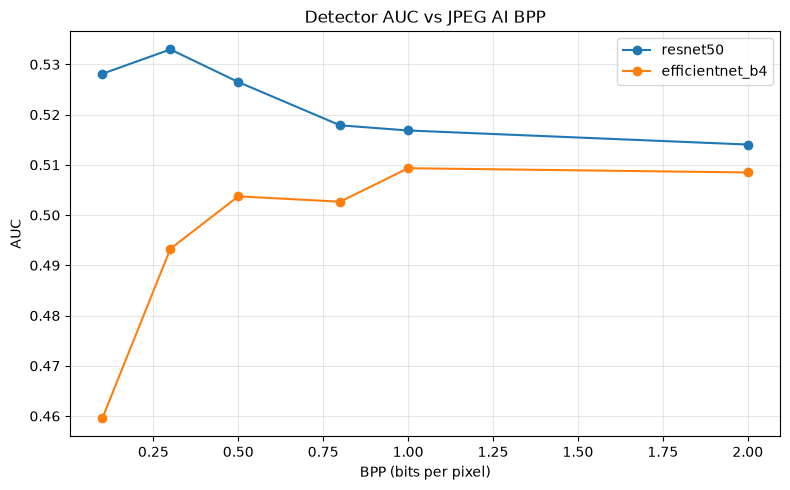

Plot saved to /home/cascatetto/ssd/Projects/jpegai-deepfake-forensics/jpegai-deepfake-forensics/results/degradation_auc.png


In [ ]:

# Phase 1: Evaluate fine-tuned baseline on original test split + all BPP-compressed sets.
# This shows how JPEG AI compression degrades detector performance.

phase1_results = {}

# Original test split
_m = evaluate_detector(baseline_model, make_list_loader(TEST_SAMPLES))
phase1_results["original"] = _m
print(f"original | AUC={_m['auc']:.4f}  acc={_m['accuracy']:.4f}")

# Compressed at each BPP (all 150 images per class)
for bpp in tqdm(BPP_LEVELS, desc="BPP levels"):
    bpp_tag = f"bpp_{int(bpp*100):03d}"
    bpp_dir = COMPRESSED_DIR / bpp_tag
    if not bpp_dir.exists():
        print(f"  SKIP {bpp_tag} (not found)")
        continue
    _m = evaluate_detector(baseline_model, make_dataloader(bpp_dir))
    phase1_results[bpp] = _m
    print(f"{bpp_tag} | AUC={_m['auc']:.4f}  acc={_m['accuracy']:.4f}")

# ── Save CSV ──────────────────────────────────────────────────────────────────
rows = [{"detector": BASELINE_DET, "strategy": "baseline", "bpp": k,
         "auc": v["auc"], "accuracy": v["accuracy"], "f1": v["f1"]}
        for k, v in phase1_results.items()]
pd.DataFrame(rows).to_csv(RESULTS_DIR / "degradation_results.csv", index=False)
print(f"\nSaved → {RESULTS_DIR / 'degradation_results.csv'}")

# ── Plot degradation curve ────────────────────────────────────────────────────
_auc_bpp = {k: v["auc"] for k, v in phase1_results.items() if k != "original"}
plot_degradation_curve({"Baseline": _auc_bpp}, metric="auc",
                       title=f"Phase 1 — {BASELINE_DET} AUC vs JPEG AI BPP")
print(f"Plot saved → {RESULTS_DIR / 'degradation_auc.png'}")


### 7.2 Phase 2 — Frequency-domain forensic analysis

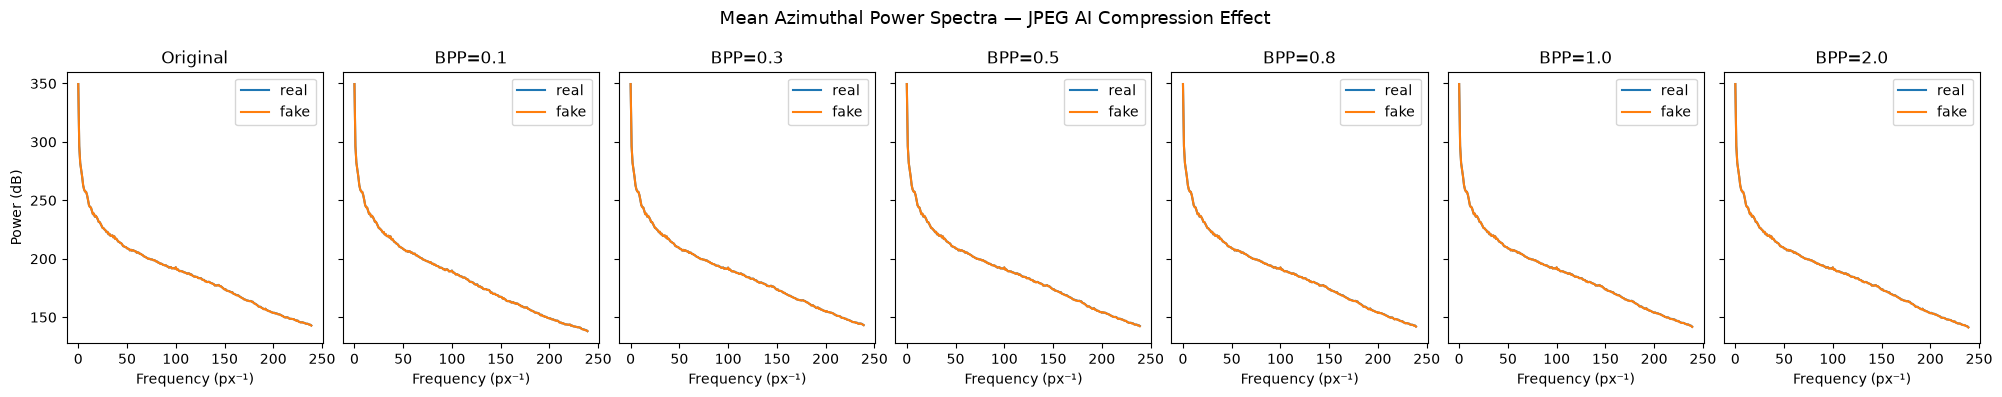

In [11]:

# Compare power spectra across: original-real, original-fake, compressed-real, compressed-fake

N_SAMPLES = 100  # images per category

def collect_spectra(img_dir: Path, label: str, n: int = N_SAMPLES) -> np.ndarray:
    paths = list(img_dir.rglob("*.png")) + list(img_dir.rglob("*.jpg"))
    paths = sorted(paths)[:n]
    spectra = []
    for p in paths:
        gray = np.array(Image.open(p).convert("L"))
        spectra.append(azimuthal_average(compute_power_spectrum(gray)))
    # Truncate all profiles to the minimum length (images may have different sizes)
    min_len = min(len(s) for s in spectra)
    return np.stack([s[:min_len] for s in spectra])  # shape (n, min_len)


fig, axes = plt.subplots(1, len(BPP_LEVELS) + 1, figsize=(20, 4), sharey=True)

# Original
for cls in ["real", "fake"]:
    specs = collect_spectra(ORIGINAL_DIR / cls, cls)
    axes[0].plot(specs.mean(axis=0), label=cls)
axes[0].set_title("Original")
axes[0].set_xlabel("Frequency (px⁻¹)")
axes[0].set_ylabel("Power (dB)")
axes[0].legend()

# Compressed at each BPP
for i, bpp in enumerate(BPP_LEVELS):
    bpp_tag = f"bpp_{int(bpp*100):03d}"
    ax = axes[i + 1]
    for cls in ["real", "fake"]:
        bpp_cls_dir = COMPRESSED_DIR / bpp_tag / cls
        if not bpp_cls_dir.exists():
            continue
        specs = collect_spectra(bpp_cls_dir, cls)
        ax.plot(specs.mean(axis=0), label=cls)
    ax.set_title(f"BPP={bpp}")
    ax.set_xlabel("Frequency (px⁻¹)")
    ax.legend()

plt.suptitle("Mean Azimuthal Power Spectra — JPEG AI Compression Effect", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "power_spectra.png", dpi=150)
plt.show()


### 7.3 DCT coefficient distributions

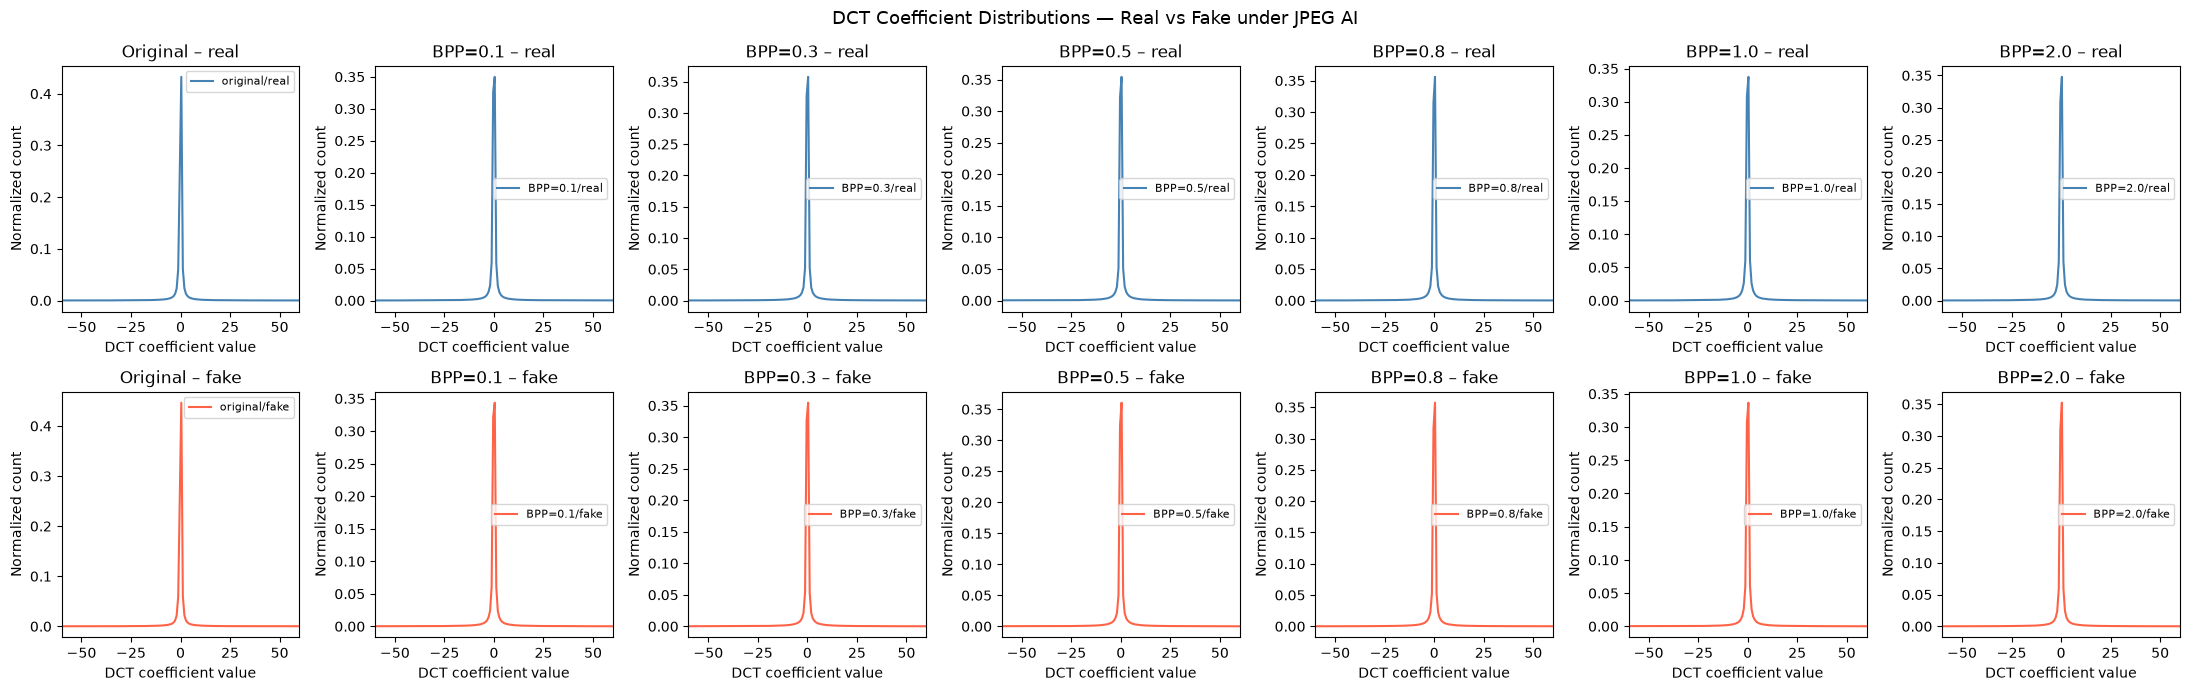

In [12]:
fig, axes = plt.subplots(2, len(BPP_LEVELS) + 1, figsize=(22, 7))

def plot_dct_hist(ax, img_dir: Path, label: str, color: str, n: int = 50) -> None:
    paths = (list(img_dir.rglob("*.png")) + list(img_dir.rglob("*.jpg")))[:n]
    all_hists = []
    for p in paths:
        gray = np.array(Image.open(p).convert("L"))
        hist, edges = compute_dct_histogram(gray)
        all_hists.append(hist / hist.sum())  # normalize
    centers = (edges[:-1] + edges[1:]) / 2
    mean_hist = np.mean(all_hists, axis=0)
    ax.plot(centers, mean_hist, color=color, label=label, linewidth=1.5)
    ax.set_xlim(-60, 60)
    ax.set_xlabel("DCT coefficient value")
    ax.set_ylabel("Normalized count")
    ax.legend(fontsize=8)

for row, cls in enumerate(["real", "fake"]):
    color = "steelblue" if cls == "real" else "tomato"
    # Original
    plot_dct_hist(axes[row][0], ORIGINAL_DIR / cls, f"original/{cls}", color)
    axes[row][0].set_title(f"Original – {cls}")
    # Compressed
    for i, bpp in enumerate(BPP_LEVELS):
        bpp_tag = f"bpp_{int(bpp*100):03d}"
        bpp_cls_dir = COMPRESSED_DIR / bpp_tag / cls
        ax = axes[row][i + 1]
        if bpp_cls_dir.exists():
            plot_dct_hist(ax, bpp_cls_dir, f"BPP={bpp}/{cls}", color)
        ax.set_title(f"BPP={bpp} – {cls}")

plt.suptitle("DCT Coefficient Distributions — Real vs Fake under JPEG AI", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dct_histograms.png", dpi=150)
plt.show()

### 7.4 Phase 3 — Mitigation comparison

In [ ]:

# ── Helper: JPEG compression augmentation ────────────────────────────────────
def _jpeg_compress(img: Image.Image, quality: int) -> Image.Image:
    arr = np.array(img)
    _, enc = cv2.imencode(".jpg", cv2.cvtColor(arr, cv2.COLOR_RGB2BGR),
                           [cv2.IMWRITE_JPEG_QUALITY, quality])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return Image.fromarray(cv2.cvtColor(dec, cv2.COLOR_BGR2RGB))

_jpeg_aug_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomApply([T.Lambda(lambda img: _jpeg_compress(img, random.randint(30, 95)))], p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def _eval_on_all_sets(model):
    """Evaluate model on original test split + all BPP compressed sets."""
    results = {}
    results["original"] = evaluate_detector(model, make_list_loader(TEST_SAMPLES))
    for bpp in BPP_LEVELS:
        bpp_dir = COMPRESSED_DIR / f"bpp_{int(bpp*100):03d}"
        if bpp_dir.exists():
            results[bpp] = evaluate_detector(model, make_dataloader(bpp_dir))
    return results


# ── Mitigation 1: Fine-tune on original train + ALL compressed images ─────────
# Adds all 150×6 BPP compressed images to the training pool (real + fake).
mit1_ckpt = CHECKPOINTS_DIR / f"{BASELINE_DET}_mit1_augmented.pth"

if mit1_ckpt.exists():
    print(f"MIT-1 checkpoint found — skipping training: {mit1_ckpt}")
else:
    aug_samples = list(TRAIN_SAMPLES)
    for bpp in BPP_LEVELS:
        for cls, lbl in [("real", 0), ("fake", 1)]:
            d = COMPRESSED_DIR / f"bpp_{int(bpp*100):03d}" / cls
            if d.exists():
                aug_samples += [(p, lbl) for p in sorted(d.rglob("*.png"))]
    print(f"MIT-1 augmented train set: {len(aug_samples)} samples")
    _m1 = load_detector(BASELINE_DET)
    finetune(_m1,
             make_list_loader(aug_samples, shuffle=True),
             make_list_loader(TEST_SAMPLES),
             epochs=BASELINE_EPOCHS,
             save_path=mit1_ckpt)

mit1_model = load_detector(BASELINE_DET, pretrained=False)
mit1_model.load_state_dict(torch.load(mit1_ckpt, map_location=DEVICE, weights_only=True))
mit1_model.eval()

print("Evaluating MIT-1...")
mit1_results = _eval_on_all_sets(mit1_model)
for k, v in mit1_results.items():
    print(f"  [MIT1] {k} | AUC={v['auc']:.4f}  acc={v['accuracy']:.4f}")


# ── Mitigation 2: Fine-tune with JPEG augmentation transform ─────────────────
mit2_ckpt = CHECKPOINTS_DIR / f"{BASELINE_DET}_mit2_jpegaug.pth"

if mit2_ckpt.exists():
    print(f"\nMIT-2 checkpoint found — skipping training: {mit2_ckpt}")
else:
    print("\nMIT-2: fine-tuning with JPEG augmentation...")
    _m2 = load_detector(BASELINE_DET)
    finetune(_m2,
             make_list_loader(TRAIN_SAMPLES, shuffle=True, transform=_jpeg_aug_transform),
             make_list_loader(TEST_SAMPLES),
             epochs=BASELINE_EPOCHS,
             save_path=mit2_ckpt)

mit2_model = load_detector(BASELINE_DET, pretrained=False)
mit2_model.load_state_dict(torch.load(mit2_ckpt, map_location=DEVICE, weights_only=True))
mit2_model.eval()

print("Evaluating MIT-2...")
mit2_results = _eval_on_all_sets(mit2_model)
for k, v in mit2_results.items():
    print(f"  [MIT2] {k} | AUC={v['auc']:.4f}  acc={v['accuracy']:.4f}")


# ── Save combined CSV ─────────────────────────────────────────────────────────
rows = []
for strategy, res in [("baseline",     phase1_results),
                       ("mit1_augmented", mit1_results),
                       ("mit2_jpegaug",   mit2_results)]:
    for k, v in res.items():
        rows.append({"detector": BASELINE_DET, "strategy": strategy, "bpp": k,
                     "auc": v["auc"], "accuracy": v["accuracy"], "f1": v["f1"]})
pd.DataFrame(rows).to_csv(RESULTS_DIR / "mitigation_results.csv", index=False)
print(f"\nSaved → {RESULTS_DIR / 'mitigation_results.csv'}")


Mitigation cells ready. Run fine-tuning blocks above, then populate mitigation_summary.


### 7.5 Final summary plot — before vs after mitigation

In [ ]:

# Final comparison: baseline vs mitigation 1 vs mitigation 2

compare = {
    "Baseline (no mitigation)":        {k: v["auc"] for k, v in phase1_results.items() if k != "original"},
    "MIT-1 (compression-augmented FT)": {k: v["auc"] for k, v in mit1_results.items()   if k != "original"},
    "MIT-2 (JPEG aug FT)":              {k: v["auc"] for k, v in mit2_results.items()    if k != "original"},
}
plot_degradation_curve(compare, metric="auc",
                       title=f"Mitigation Comparison — {BASELINE_DET}")
print(f"Plot saved → {RESULTS_DIR / 'degradation_auc.png'}")

# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for strat, res_dict in [("Baseline",   phase1_results),
                         ("MIT-1 (comp. aug)", mit1_results),
                         ("MIT-2 (JPEG aug)",  mit2_results)]:
    for k, v in sorted(res_dict.items(), key=lambda x: (str(x[0]) == "original", x[0])):
        summary_rows.append({"Strategy": strat, "BPP": k,
                              "AUC": f"{v['auc']:.4f}", "Acc": f"{v['accuracy']:.4f}"})
print(pd.DataFrame(summary_rows).to_string(index=False))


Populate 'compare' dict with real results and uncomment the plot call.
